# How to say ***Hello World!*** in ML?

Dados los siguientes datos:

<div class="instructions"><div class="inner">
<div class="devsite-table-wrapper">
  <table class="vertical-rules">
    <tbody>
      <tr>
        <td colspan="1" rowspan="1"><p>X:</p></td>
        <td colspan="1" rowspan="1"><p>-1.0</p></td>
        <td colspan="1" rowspan="1"><p>0.0</p></td>
        <td colspan="1" rowspan="1"><p>1.0</p></td>
        <td colspan="1" rowspan="1"><p>2.0</p></td>
        <td colspan="1" rowspan="1"><p>3.0</p></td>
        <td colspan="1" rowspan="1"><p>4.0</p></td>
      </tr>
      <tr>
        <td colspan="1" rowspan="1"><p>Y:</p></td>
        <td colspan="1" rowspan="1"><p>-4.0</p></td>
        <td colspan="1" rowspan="1"><p>1.0</p></td>
        <td colspan="1" rowspan="1"><p>6.0</p></td>
        <td colspan="1" rowspan="1"><p>11.0</p></td>
        <td colspan="1" rowspan="1"><p>16.0</p></td>
        <td colspan="1" rowspan="1"><p>21.0</p></td>
      </tr>
    </tbody>
  </table>
</div>
</div></div>

Realice las operaciones dadas para una regresión lineal simple y visualizar los datos dados con **xs** y **ys**. Muestre el gráfico para analizar el comportamiento de los datos.

$Recordando$ $la$ $Regresión$ $Lineal$ $Simple:$

$
\overline{y} = β\overline{x} + α
$

Entrene una red neuronal para hacer coincidir **xs** con **ys**.

De modo que un predictor para un nuevo valor de X proporcione un valor flotante muy cercano a la respuesta deseada, es decir, **print(modelo.predict([X]))** debe dar un resultado satisfactorio.

La infraestructura de prueba, espera un modelo entrenado que acepte una forma de entrada de [1].

Realice un test de entrenamiento para verificar las epocas dadas y visualice el comportamiento de las perdidas según el algoritmo utilizado.  

Guarde el modelo anterior en un archivo con el nombre y tipo de dato **mymodel.h5**

**Solución:** https://colab.research.google.com/drive/15euxlQOV2v-8QwDs7GrR2b4QJZ1C5l27?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1LEJVu0Wz-HN3jAQX-uKE9JRrd1181EHm?usp=sharing

## 1. Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 2. Datos

In [2]:
xs = np.arange(-1, 5, dtype=float)
ys = np.array([-4.0, 1.0, 6.0, 11.0, 16.0, 21.0], dtype=float)
print(f"xs = {xs}\nys = {ys}")

xs = [-1.  0.  1.  2.  3.  4.]
ys = [-4.  1.  6. 11. 16. 21.]


## 3. Regresion lineal simple

Antes de entrenar la red, calculamos la recta de regresion de forma analitica.

In [3]:
beta, alfa = np.polyfit(xs, ys, 1)
print(f"y = {round(beta, 1)}x + {round(alfa, 1)}")

y = 5.0x + 1.0


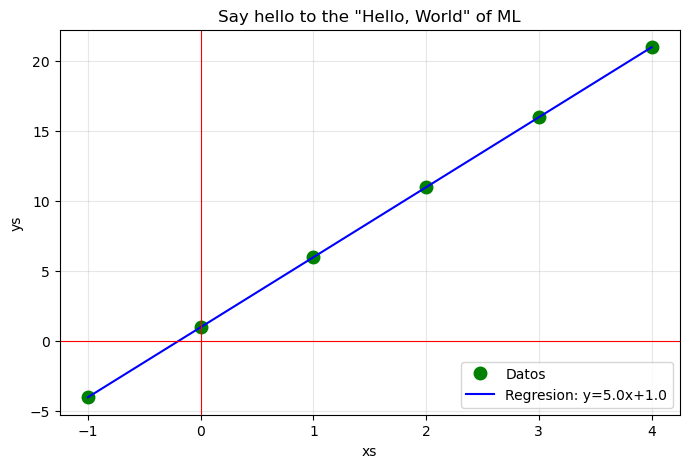

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(xs, ys, "o", color="green", markersize=9, label="Datos")
plt.plot(xs, beta * xs + alfa, color="blue", label=f"Regresion: y={beta:.1f}x+{alfa:.1f}")
plt.axhline(y=0, color="red", lw=0.8); plt.axvline(x=0, color="red", lw=0.8)
plt.title('Say hello to the "Hello, World" of ML')
plt.xlabel("xs"); plt.ylabel("ys"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4. Red neuronal (perceptron simple)

Una unica neurona con una entrada de forma `[1]`. Al entrenar con descenso de gradiente (`sgd`) y error cuadratico medio (`mse`), la neurona deberia converger a los mismos pesos que la regresion lineal analitica.

In [5]:
capa = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([tf.keras.Input(shape=(1,)), capa])
modelo.compile(optimizer="sgd", loss="mse")
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("Comenzando entrenamiento...")
historial = modelo.fit(xs, ys, epochs=500, verbose=0)
print("Entrenamiento finalizado")

Comenzando entrenamiento...


Entrenamiento finalizado


## 5. Comportamiento de la perdida

Visualizamos como decrece el error  a lo largo de las epocas: es la forma de comprobar que el modelo realmente esta aprendiendo.

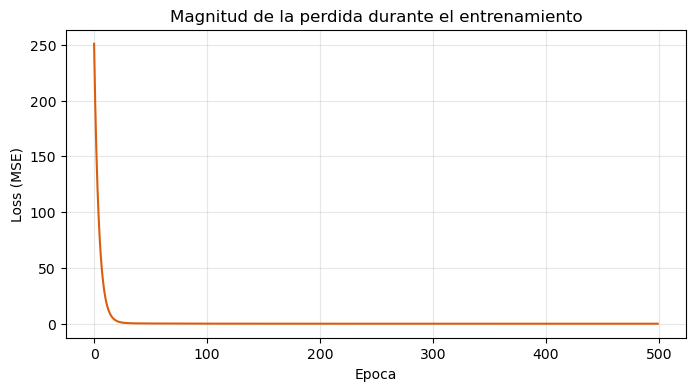

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"], color="#d95f0e")
plt.title("Magnitud de la perdida durante el entrenamiento")
plt.xlabel("Epoca"); plt.ylabel("Loss (MSE)"); plt.grid(alpha=0.3); plt.show()

## 6. Prediccion

La infraestructura de prueba espera un modelo que acepte una entrada de forma
`[1]`. Predecimos un valor nuevo (en una sesion interactiva podrias sustituir el
valor fijo por `float(input(...))`).

In [8]:
valor = 10.0
prediccion = modelo.predict(np.array([[valor]]), verbose=0)[0, 0]
print(f"Prediccion de la red para x = {valor}: {prediccion:.4f}")
print(f"Valor esperado (y = {beta:.0f}x + {alfa:.0f})    : {beta*valor + alfa:.4f}")
print(f"\nPesos aprendidos por la neurona -> beta={capa.get_weights()[0][0,0]:.4f}, "
      f"alfa={capa.get_weights()[1][0]:.4f}")

Prediccion de la red para x = 10.0: 50.9870
Valor esperado (y = 5x + 1)    : 51.0000

Pesos aprendidos por la neurona -> beta=4.9981, alfa=1.0058


## 7. Guardar el modelo

In [9]:
modelo.save("mymodel.h5")
print("Modelo guardado en mymodel.h5")

Modelo guardado en mymodel.h5


Una sola neurona lineal es equivalente a una **regresion lineal simple**: tras el entrenamiento, los pesos `beta` y `alfa` convergen a la pendiente y la ordenada calculadas con `np.polyfit`.